In [36]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [37]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1. Для изображения sar_3.jpg найти наиболее протяженный участок (выделить линии при помощи преобразования Хафа).

In [38]:
canny = cv2.Canny(image_gray,100,150,apertureSize = 3)
lines = cv2.HoughLines(canny, 1, np.pi / 180, 140)

In [39]:
import math 

max_length = 0
longest_line = None
if lines is not None:
        for i in range(0, len(lines)):
            rho = lines[i][0][0]
            theta = lines[i][0][1]
            a = math.cos(theta)
            b = math.sin(theta)
            x0 = a * rho
            y0 = b * rho
            pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
            pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
            length = np.sqrt((pt1[0] - pt2[0]) ** 2 + (pt1[1] - pt2[1]) ** 2)
            if length > max_length:
                max_length = length
                longest_line = (pt1, pt2)
        if longest_line is not None:
            image_with_line = image.copy();
            cv2.line(image_with_line, longest_line[0], longest_line[1], (0, 0, 255), 3, cv2.LINE_AA)

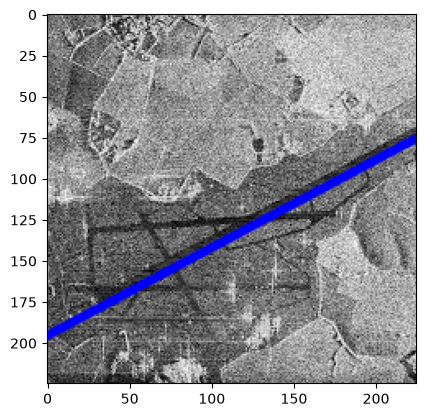

In [40]:
plt.imshow(image_with_line, cmap="gray")

# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

## Точечная бинаризация

In [41]:
import copy

bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

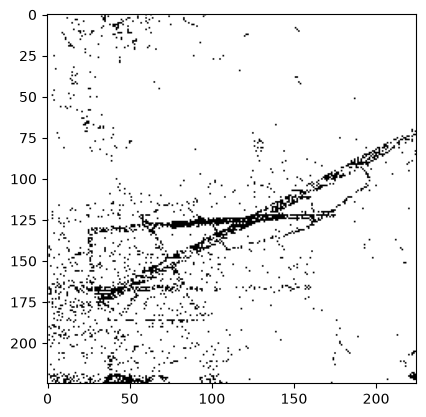

In [42]:
plt.imshow(bin_img, cmap="gray")

## Бинаризация Отсу

In [43]:
_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

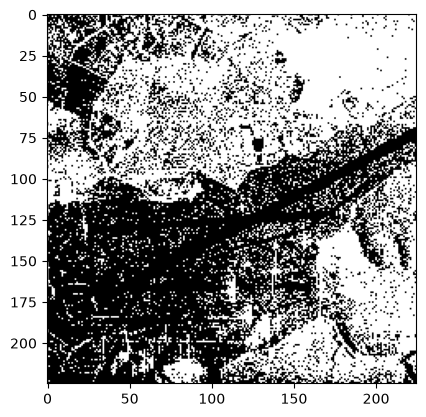

In [44]:
plt.imshow(th2, cmap="gray")

## Адаптивная бинаризация

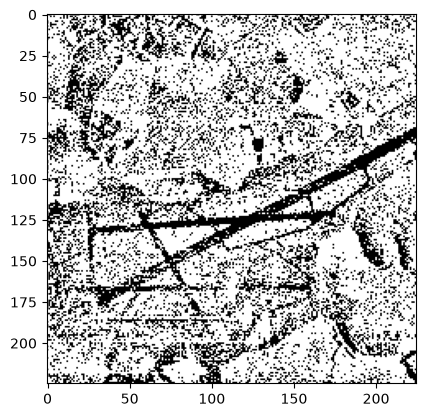

In [45]:
th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,71,21)
plt.imshow(th3, cmap="gray")

## Оператор Собеля

In [46]:
scale = 1
delta = 0
ddepth = cv2.CV_16S
grad_x = cv2.Sobel(image_gray, ddepth, 1, 0, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)
grad_y = cv2.Sobel(image_gray, ddepth, 0, 1, ksize=3, scale=scale, delta=delta, borderType=cv2.BORDER_DEFAULT)

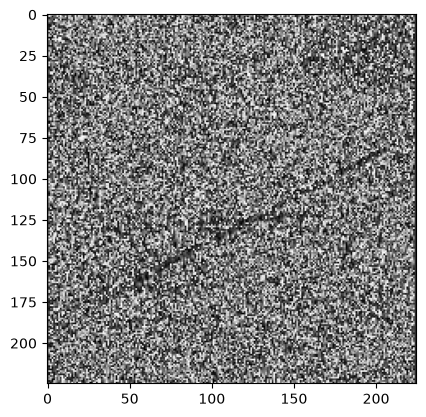

In [47]:
plt.imshow((grad_x - grad_x.min())*255, cmap="gray")

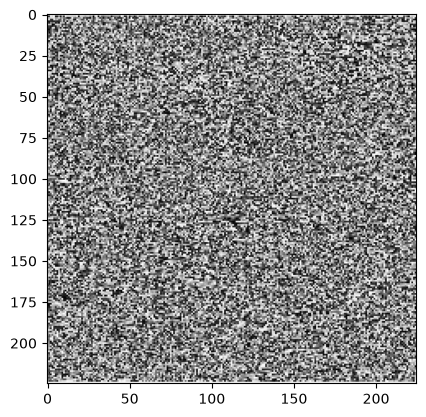

In [48]:
plt.imshow((grad_y - grad_y.min())*255, cmap="gray")

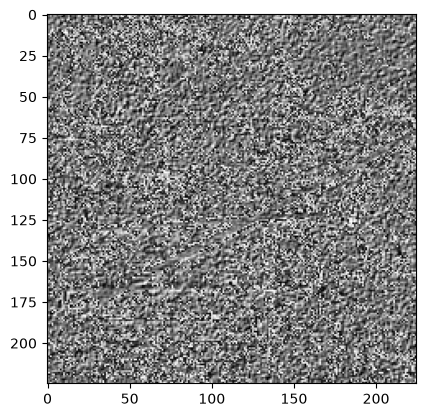

In [49]:
grad = cv2.addWeighted(grad_x, 0.5, grad_y, 0.5,0.0)
plt.imshow((grad - grad.min())*255, cmap="gray")

## Canny

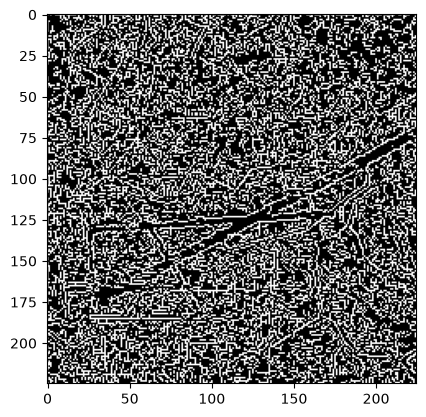

In [50]:
edges = cv2.Canny(image_gray,100,200)
plt.imshow(edges, cmap="gray")